# Laboratorio 5: ecuación radial del átomo de hidrógeno con el método de diferencias finitas

**Andrés Felipe Serrano Barrios**

Física Computacional I (0302151), grupo 001

Instituto de Física, Universidad de Antioquia

Semestre 2026-2, profesor Andrés Felipe Rivera Romero

---

# 1. Separación de variables

**Ecuación de Schrödinger.** El electrón está en el potencial del protón,
$U(r)=-\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}$, y la ecuación estacionaria es

$$-\frac{\hbar^2}{2m}\nabla^2\psi(\vec{r})+U(r)\,\psi(\vec{r})=E\,\psi(\vec{r}).$$

$U$ solo depende de $r$, así que se trabaja en coordenadas esféricas, donde

$$\nabla^2\psi=\frac{1}{r^2}\frac{\partial}{\partial r}\left(r^2\frac{\partial\psi}{\partial r}\right)
+\frac{1}{r^2\sin\theta}\frac{\partial}{\partial\theta}\left(\sin\theta\,\frac{\partial\psi}{\partial\theta}\right)
+\frac{1}{r^2\sin^2\theta}\frac{\partial^2\psi}{\partial\varphi^2}.$$

**Paso 1. Producto de funciones.** Con $\psi(r,\theta,\varphi)=R(r)\,Y(\theta,\varphi)$:

$$-\frac{\hbar^2}{2m}\left[\frac{Y}{r^2}\frac{d}{dr}\left(r^2\frac{dR}{dr}\right)
+\frac{R}{r^2\sin\theta}\frac{\partial}{\partial\theta}\left(\sin\theta\,\frac{\partial Y}{\partial\theta}\right)
+\frac{R}{r^2\sin^2\theta}\frac{\partial^2Y}{\partial\varphi^2}\right]+U\,R\,Y=E\,R\,Y.$$

**Paso 2. Separación.** Multiplicando por $-\dfrac{2mr^2}{\hbar^2\,R\,Y}$:

$$\underbrace{\frac{1}{R}\frac{d}{dr}\left(r^2\frac{dR}{dr}\right)+\frac{2mr^2}{\hbar^2}\big[E-U(r)\big]}_{\text{solo depende de }r}
+\underbrace{\frac{1}{Y}\left[\frac{1}{\sin\theta}\frac{\partial}{\partial\theta}\left(\sin\theta\,\frac{\partial Y}{\partial\theta}\right)
+\frac{1}{\sin^2\theta}\frac{\partial^2Y}{\partial\varphi^2}\right]}_{\text{solo depende de }\theta\text{ y }\varphi}=0.$$

La suma vale cero para todo $r$, $\theta$ y $\varphi$, así que cada bloque es constante. La constante
se escribe $l(l+1)$:

$$\frac{1}{R}\frac{d}{dr}\left(r^2\frac{dR}{dr}\right)+\frac{2mr^2}{\hbar^2}\big[E-U(r)\big]=l(l+1),$$

$$\frac{1}{\sin\theta}\frac{\partial}{\partial\theta}\left(\sin\theta\,\frac{\partial Y}{\partial\theta}\right)
+\frac{1}{\sin^2\theta}\frac{\partial^2Y}{\partial\varphi^2}=-l(l+1)\,Y.$$

La parte angular aporta la constante $l(l+1)$, con $l=0,1,2,\dots$

**Paso 3. Ecuación radial.** Dividiendo la ecuación en $r$ por $r^2$ y multiplicando por $R$:

$$\frac{1}{r^2}\frac{d}{dr}\left(r^2\frac{dR}{dr}\right)+\frac{2m}{\hbar^2}\big[E-U(r)\big]R
-\frac{l(l+1)}{r^2}\,R=0.$$

**Paso 4. Cambio $u=r\,R$.** Con $R=u/r$:

$$\frac{dR}{dr}=\frac{1}{r}\frac{du}{dr}-\frac{u}{r^2},\qquad r^2\frac{dR}{dr}=r\frac{du}{dr}-u,$$

$$\frac{d}{dr}\left(r^2\frac{dR}{dr}\right)=\frac{du}{dr}+r\frac{d^2u}{dr^2}-\frac{du}{dr}=r\frac{d^2u}{dr^2},
\qquad\frac{1}{r^2}\frac{d}{dr}\left(r^2\frac{dR}{dr}\right)=\frac{1}{r}\frac{d^2u}{dr^2}.$$

Reemplazando en el paso 3 y multiplicando por $-\hbar^2r/2m$:

$$-\frac{\hbar^2}{2m}\frac{d^2u}{dr^2}+\left[-\frac{e^2}{4\pi\epsilon_0}\frac{1}{r}
+\frac{\hbar^2\,l(l+1)}{2mr^2}\right]u=E\,u.$$

**Paso 5. Unidades atómicas.** Con el radio de Bohr y el hartree,

$$a_0=\frac{4\pi\epsilon_0\hbar^2}{me^2},\qquad E_h=\frac{\hbar^2}{ma_0^2}=\frac{e^2}{4\pi\epsilon_0\,a_0}=27.211\ \text{eV},$$

se cambia $r=a_0\,x$ y $E=E_h\,\varepsilon$. Como $\dfrac{d^2u}{dr^2}=\dfrac{1}{a_0^2}\dfrac{d^2u}{dx^2}$:

$$-\frac{\hbar^2}{2ma_0^2}\frac{d^2u}{dx^2}+\left[-\frac{e^2}{4\pi\epsilon_0\,a_0}\frac{1}{x}
+\frac{\hbar^2}{ma_0^2}\frac{l(l+1)}{2x^2}\right]u=E_h\,\varepsilon\,u.$$

Dividiendo por $E_h$ los tres coeficientes valen $1$. Volviendo a llamar $r$ a $x$ y $E$ a $\varepsilon$,
con $r$ en $a_0$ y $E$ en Ha:

$$-\frac{1}{2}\frac{d^2u}{dr^2}+\left[-\frac{1}{r}+\frac{l(l+1)}{2r^2}\right]u=E\,u.$$

**Paso 6. Condiciones de frontera.** Con $\int|Y|^2\,d\Omega=1$, la normalización es

$$\int|\psi|^2\,d^3r=\int_0^\infty R^2\,r^2\,dr=\int_0^\infty u^2\,dr=1,$$

así que $u\to0$ cuando $r\to\infty$. Cerca del origen domina el término $l(l+1)/2r^2$ y la ecuación
queda $u''\approx l(l+1)\,u/r^2$. Con $u=r^s$:

$$s(s-1)=l(l+1)\quad\Rightarrow\quad s=l+1\quad\text{o}\quad s=-l.$$

Con $s=-l$, $R=u/r\propto r^{-l-1}$ diverge en el origen; queda $u\sim r^{l+1}$ y $u(0)=0$. En la malla,
$r_{max}$ hace el papel del infinito:

$$\boxed{\;-\frac{1}{2}\frac{d^2u}{dr^2}+\left[-\frac{1}{r}+\frac{l(l+1)}{2r^2}\right]u=E\,u,
\qquad u(0)=0,\quad u(r_{max})=0\;}$$

In [1]:
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": False})

---

# 2. Discretización

Malla uniforme $r_i=i\,h$, con $i=0,1,\dots,N+1$, $r_{N+1}=r_{max}$ y $u_i=u(r_i)$.

**Segunda derivada centrada.** Series de Taylor alrededor de $r_i$:

$$u(r_i+h)=u(r_i)+h\,u'(r_i)+\frac{h^2}{2}\,u''(r_i)+\frac{h^3}{6}\,u'''(r_i)+\frac{h^4}{24}\,u''''(r_i)+\cdots$$

$$u(r_i-h)=u(r_i)-h\,u'(r_i)+\frac{h^2}{2}\,u''(r_i)-\frac{h^3}{6}\,u'''(r_i)+\frac{h^4}{24}\,u''''(r_i)-\cdots$$

Sumando, los términos impares se cancelan:

$$u_{i+1}+u_{i-1}=2u_i+h^2\,u''(r_i)+\frac{h^4}{12}\,u''''(r_i)+\cdots$$

$$u''(r_i)=\frac{u_{i+1}-2u_i+u_{i-1}}{h^2}-\frac{h^2}{12}\,u''''(r_i)-\cdots
\approx\frac{u_{i+1}-2u_i+u_{i-1}}{h^2},$$

con error de orden $h^2$.

**Ecuación en cada nodo.** En el nodo interior $i$, con $V_i=-\dfrac{1}{r_i}+\dfrac{l(l+1)}{2r_i^2}$:

$$-\frac{1}{2}\,\frac{u_{i+1}-2u_i+u_{i-1}}{h^2}+V_i\,u_i=E\,u_i.$$

Agrupando por nodo:

$$-\frac{1}{2h^2}\,u_{i-1}+\left[\frac{1}{h^2}+V_i\right]u_i-\frac{1}{2h^2}\,u_{i+1}=E\,u_i,
\qquad i=1,\dots,N.$$

En $i=1$ aparece $u_0=0$ y en $i=N$ aparece $u_{N+1}=0$, y esos términos se van. Las $N$ ecuaciones
juntas son

$$\begin{pmatrix}a_1&b&&&\\ b&a_2&b&&\\ &\ddots&\ddots&\ddots&\\ &&b&a_{N-1}&b\\ &&&b&a_N\end{pmatrix}
\begin{pmatrix}u_1\\ u_2\\ \vdots\\ u_{N-1}\\ u_N\end{pmatrix}
=E\begin{pmatrix}u_1\\ u_2\\ \vdots\\ u_{N-1}\\ u_N\end{pmatrix},
\qquad a_i=\frac{1}{h^2}+V_i,\quad b=-\frac{1}{2h^2}.$$

Con $N$ del orden de miles solo se guardan la diagonal y la subdiagonal.

In [2]:
paso = 0.01
r_max = 80.0
nodos = int(round(r_max/paso)) - 1

r = np.zeros(nodos)
for i in range(nodos):
    r[i] = (i + 1)*paso


def armar_matriz(l):
    """Diagonal y subdiagonal de H para el momento angular l; subdiagonal[i] acopla los nodos i-1 e i."""
    diagonal = np.zeros(nodos)
    subdiagonal = np.zeros(nodos)
    for i in range(nodos):
        diagonal[i] = 1.0/paso**2 - 1.0/r[i] + l*(l + 1)/(2.0*r[i]**2)
        subdiagonal[i] = -1.0/(2.0*paso**2)
    return diagonal, subdiagonal


print(f"h = {paso} a0, r_max = {r_max} a0")
print(f"N = {nodos} nodos interiores")

h = 0.01 a0, r_max = 80.0 a0
N = 7999 nodos interiores


---

# 3. Valores propios

**Pivotes de la eliminación.** Para un número $x$ se hace eliminación gaussiana sobre
$\mathbf{H}-x\,\mathbf{I}$. El primer pivote es $q_1=a_1-x$. Para anular la $b$ que está debajo, a la
fila 2 se le resta la fila 1 multiplicada por $b/q_1$, y el elemento diagonal de la fila 2 pasa a ser

$$q_2=(a_2-x)-\frac{b}{q_1}\,b.$$

Cada fila solo tiene un vecino debajo, así que fila por fila:

$$q_1=a_1-x,\qquad q_i=(a_i-x)-\frac{b^2}{q_{i-1}},\quad i=2,\dots,N.$$

El resultado es $\mathbf{H}-x\,\mathbf{I}=\mathbf{L}\,\mathbf{D}\,\mathbf{L}^T$, con
$\mathbf{D}=\mathrm{diag}(q_1,\dots,q_N)$ y $\mathbf{L}$ bidiagonal inferior con unos en la diagonal
y $b/q_{i-1}$ debajo.

**Conteo de Sturm.** Los valores propios de $\mathbf{H}-x\,\mathbf{I}$ son $E_k-x$. Por la ley de
inercia de Sylvester, $\mathbf{L}\,\mathbf{D}\,\mathbf{L}^T$ y $\mathbf{D}$ tienen la misma cantidad
de valores propios negativos, entonces

$$n_<(x)=\#\{\,i:\ q_i<0\,\}=\#\{\,k:\ E_k<x\,\}.$$

**Bisección.** Con los valores propios ordenados, $E_0<E_1<\cdots$, el número $k$ está en
$[x_a,x_b]$ si $n_<(x_a)\le k<n_<(x_b)$. Se evalúa el punto medio $x=(x_a+x_b)/2$: si $n_<(x)>k$,
entonces $E_k<x$ y el intervalo pasa a $[x_a,x]$; si no, pasa a $[x,x_b]$. Se arranca con
$x_a=\min_i a_i-2|b|$, la cota de Gershgorin, y $x_b=0$, porque los estados ligados tienen $E<0$, y
se para cuando el intervalo mide menos de $10^{-11}$ Ha. Para cada $l$, el valor propio $k$ es el
estado $n=k+l+1$.

**Iteración inversa.** Un vector cualquiera se escribe en la base de vectores propios,
$\mathbf{v}=\sum_k c_k\,\mathbf{u}_k$. Como $(\mathbf{H}-\sigma\,\mathbf{I})\,\mathbf{u}_k=(E_k-\sigma)\,\mathbf{u}_k$:

$$\mathbf{w}=(\mathbf{H}-\sigma\,\mathbf{I})^{-1}\,\mathbf{v}=\sum_k\frac{c_k}{E_k-\sigma}\,\mathbf{u}_k.$$

Con $\sigma=E_{nl}+10^{-9}$, el coeficiente de $\mathbf{u}_{nl}$ queda multiplicado por un número del
orden de $10^{9}$ y los demás por $1/|E_k-\sigma|$, que es mucho menor; tres pasos normalizando dejan
solo $\mathbf{u}_{nl}$. En cada paso no se invierte la matriz, se resuelve
$(\mathbf{H}-\sigma\,\mathbf{I})\,\mathbf{w}=\mathbf{v}$.

**Algoritmo de Thomas.** La fila $i$ del sistema es $b\,w_{i-1}+(a_i-\sigma)\,w_i+b\,w_{i+1}=v_i$. La
primera fila, dividida por $a_1-\sigma$, queda $w_1+c_1\,w_2=g_1$ con

$$c_1=\frac{b}{a_1-\sigma},\qquad g_1=\frac{v_1}{a_1-\sigma}.$$

Si la fila anterior ya quedó como $w_{i-1}=g_{i-1}-c_{i-1}\,w_i$, al reemplazarla en la fila $i$:

$$(a_i-\sigma-b\,c_{i-1})\,w_i+b\,w_{i+1}=v_i-b\,g_{i-1}\quad\Rightarrow\quad w_i+c_i\,w_{i+1}=g_i,$$

$$c_i=\frac{b}{a_i-\sigma-b\,c_{i-1}},\qquad g_i=\frac{v_i-b\,g_{i-1}}{a_i-\sigma-b\,c_{i-1}}.$$

La última fila no tiene $w_{N+1}$, y la sustitución hacia atrás es

$$w_N=g_N,\qquad w_i=g_i-c_i\,w_{i+1},\quad i=N-1,\dots,1.$$

**Normalización.** $\int_0^{r_{max}}u^2\,dr=1$ con la regla del trapecio; con $u_0=u_{N+1}=0$ queda
$h\sum_{i=1}^{N}u_i^2$. El signo se fija con $u_1>0$, igual que la solución analítica.

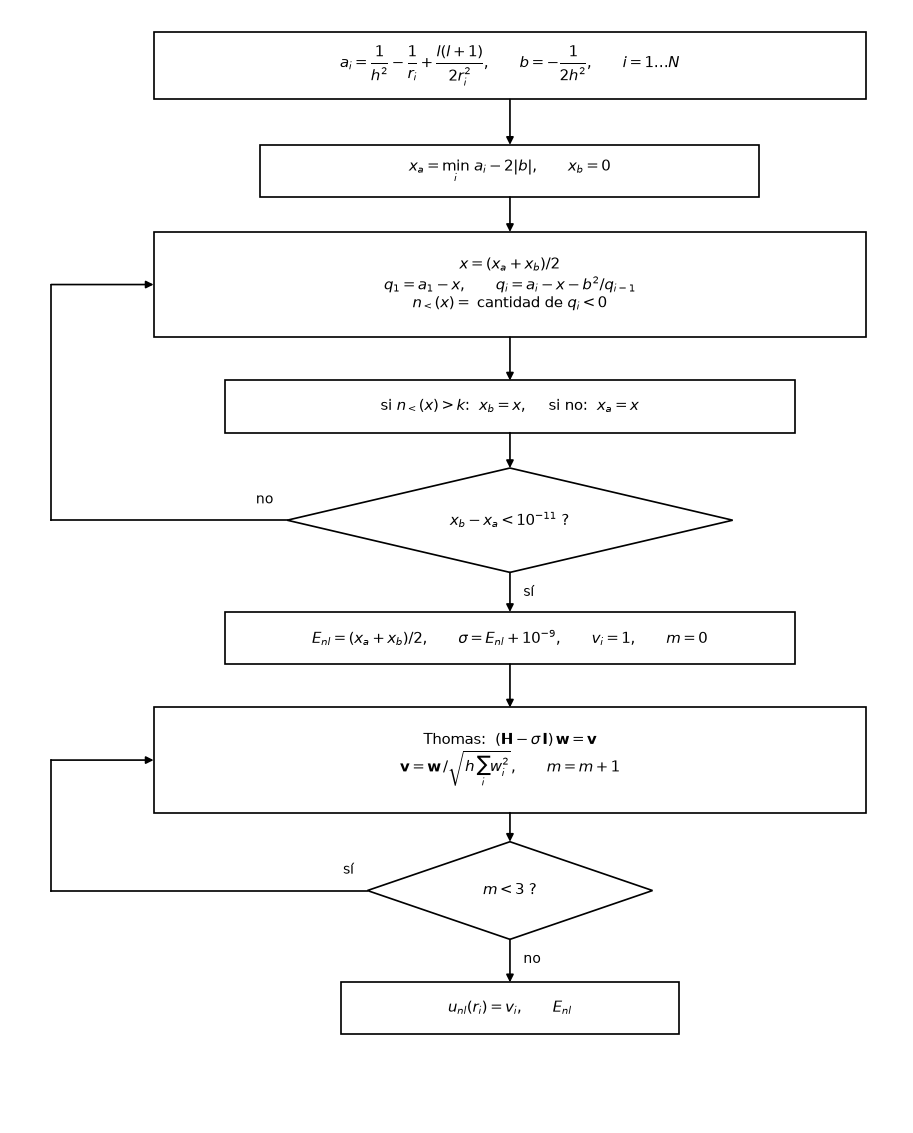

In [3]:
def conteo_sturm(diagonal, subdiagonal, x):
    """Cantidad de valores propios de H menores que x."""
    cuenta = 0
    q = diagonal[0] - x
    if q < 0.0:
        cuenta += 1
    for i in range(1, nodos):
        if q == 0.0:
            q = 1e-300
        q = (diagonal[i] - x) - subdiagonal[i]*subdiagonal[i]/q
        if q < 0.0:
            cuenta += 1
    return cuenta


def cota_inferior(diagonal, subdiagonal):
    """Cota de Gershgorin por debajo del espectro."""
    cota = diagonal[0] - abs(subdiagonal[1])
    for i in range(1, nodos):
        radio = abs(subdiagonal[i])
        if i + 1 < nodos:
            radio += abs(subdiagonal[i+1])
        if diagonal[i] - radio < cota:
            cota = diagonal[i] - radio
    return cota


def biseccion(diagonal, subdiagonal, k, tolerancia=1e-11):
    """Valor propio numero k (desde 0) por biseccion sobre el conteo de Sturm."""
    x_a = cota_inferior(diagonal, subdiagonal)
    x_b = 0.0
    while x_b - x_a > tolerancia:
        x = 0.5*(x_a + x_b)
        if conteo_sturm(diagonal, subdiagonal, x) > k:
            x_b = x
        else:
            x_a = x
    return 0.5*(x_a + x_b)


def thomas(diagonal, subdiagonal, sigma, v):
    """Resuelve (H - sigma I) w = v para H tridiagonal simetrica."""
    c = np.zeros(nodos)
    g = np.zeros(nodos)
    pivote = diagonal[0] - sigma
    c[0] = subdiagonal[1]/pivote
    g[0] = v[0]/pivote
    for i in range(1, nodos):
        pivote = (diagonal[i] - sigma) - subdiagonal[i]*c[i-1]
        if i + 1 < nodos:
            c[i] = subdiagonal[i+1]/pivote
        g[i] = (v[i] - subdiagonal[i]*g[i-1])/pivote
    w = np.zeros(nodos)
    w[nodos-1] = g[nodos-1]
    for i in range(nodos-2, -1, -1):
        w[i] = g[i] - c[i]*w[i+1]
    return w


def trapecio_cuadrado(f):
    """Integral de f^2 entre 0 y r_max con f nula en los dos extremos."""
    suma = 0.0
    for i in range(nodos):
        suma += f[i]*f[i]
    return paso*suma


def iteracion_inversa(diagonal, subdiagonal, energia, pasos=3):
    """Funcion u normalizada del valor propio energia."""
    sigma = energia + 1e-9
    v = np.zeros(nodos)
    for i in range(nodos):
        v[i] = 1.0
    for m in range(pasos):
        w = thomas(diagonal, subdiagonal, sigma, v)
        norma = math.sqrt(trapecio_cuadrado(w))
        for i in range(nodos):
            v[i] = w[i]/norma
    if v[0] < 0.0:
        for i in range(nodos):
            v[i] = -v[i]
    return v

In [4]:
n_max = 4
letras = "spd"
energias = {}
funciones = {}

reloj = time.perf_counter()
for l in range(3):
    diagonal, subdiagonal = armar_matriz(l)
    for n in range(l + 1, n_max + 1):
        energias[(n, l)] = biseccion(diagonal, subdiagonal, n - l - 1)
        funciones[(n, l)] = iteracion_inversa(diagonal, subdiagonal, energias[(n, l)])
        print(f"{n}{letras[l]}  E = {energias[(n, l)]:.8f} Ha")

print(f"{len(energias)} estados en {time.perf_counter() - reloj:.1f} s")

1s  E = -0.49998750 Ha


2s  E = -0.12499922 Ha


3s  E = -0.05555540 Ha


4s  E = -0.03124995 Ha


2p  E = -0.12500026 Ha


3p  E = -0.05555568 Ha


4p  E = -0.03125006 Ha


3d  E = -0.05555557 Ha


4d  E = -0.03125001 Ha
9 estados en 1.3 s


---

# 4. Energías

**Solución analítica.** Los estados ligados tienen $E<0$ y se escribe $E=-\kappa^2/2$, con
$\kappa>0$. Multiplicando la ecuación radial por $-2$:

$$\frac{d^2u}{dr^2}+\left[-\kappa^2+\frac{2}{r}-\frac{l(l+1)}{r^2}\right]u=0.$$

**Variable adimensional.** Con $\rho=2\kappa r$:

$$\frac{d^2u}{dr^2}=4\kappa^2\,\frac{d^2u}{d\rho^2},\qquad\frac{2}{r}=\frac{4\kappa}{\rho},
\qquad\frac{1}{r^2}=\frac{4\kappa^2}{\rho^2},$$

y dividiendo por $4\kappa^2$:

$$\frac{d^2u}{d\rho^2}+\left[-\frac{1}{4}+\frac{\lambda}{\rho}-\frac{l(l+1)}{\rho^2}\right]u=0,
\qquad\lambda=\frac{1}{\kappa}.$$

**Extremos.** Para $\rho\to\infty$ queda $u''\approx u/4$, con soluciones $e^{\pm\rho/2}$, y la
normalizable es $e^{-\rho/2}$. Para $\rho\to0$, $u\sim\rho^{l+1}$ por el paso 6. Se propone

$$u(\rho)=\rho^{l+1}\,e^{-\rho/2}\,v(\rho).$$

**Derivadas.**

$$\frac{du}{d\rho}=\rho^{l}\,e^{-\rho/2}\left[\left(l+1-\frac{\rho}{2}\right)v+\rho\,v'\right],$$

$$\frac{d^2u}{d\rho^2}=\rho^{l-1}\,e^{-\rho/2}\left[\rho^2\,v''+\rho\,(2l+2-\rho)\,v'
+\left(l(l+1)-(l+1)\,\rho+\frac{\rho^2}{4}\right)v\right].$$

**Ecuación para $v$.** El otro término de la ecuación es

$$\left[-\frac{1}{4}+\frac{\lambda}{\rho}-\frac{l(l+1)}{\rho^2}\right]u
=\rho^{l-1}\,e^{-\rho/2}\left[-\frac{\rho^2}{4}+\lambda\,\rho-l(l+1)\right]v.$$

Al sumar se cancelan $l(l+1)$ y $\rho^2/4$; dividiendo por $\rho^{l}\,e^{-\rho/2}$:

$$\rho\,v''+(2l+2-\rho)\,v'+(\lambda-l-1)\,v=0.$$

**Serie de potencias.** Con $v=\sum_{j\ge0}c_j\,\rho^j$:

$$\rho\,v''=\sum_{j\ge0}(j+1)\,j\,c_{j+1}\,\rho^j,\qquad v'=\sum_{j\ge0}(j+1)\,c_{j+1}\,\rho^j,
\qquad\rho\,v'=\sum_{j\ge0}j\,c_j\,\rho^j.$$

El coeficiente de $\rho^j$ tiene que ser cero:

$$(j+1)\,j\,c_{j+1}+(2l+2)(j+1)\,c_{j+1}-j\,c_j+(\lambda-l-1)\,c_j=0,$$

$$c_{j+1}=\frac{j+l+1-\lambda}{(j+1)(j+2l+2)}\,c_j.$$

**Cuantización.** Si la serie no se corta, para $j$ grande $c_{j+1}/c_j\to1/j$, el mismo cociente de
la serie de $e^{\rho}$; entonces $v\sim e^{\rho}$ y $u\sim\rho^{l+1}e^{\rho/2}$ no es normalizable. La
serie se corta en algún $j_{max}=0,1,2,\dots$ solo si $j_{max}+l+1-\lambda=0$:

$$\lambda=n=j_{max}+l+1,\qquad n=1,2,\dots,\qquad 0\le l\le n-1.$$

Con $\kappa=1/\lambda=1/n$:

$$\boxed{E_n=-\frac{\kappa^2}{2}=-\frac{1}{2n^2}\ \text{Ha}}$$

La energía depende solo de $n$: para un mismo $n$, todos los $l$ tienen la misma energía.

In [5]:
filas = []
for (n, l), energia in energias.items():
    exacta = -1.0/(2.0*n*n)
    filas.append({"estado": f"{n}{letras[l]}", "n": n, "l": l,
                  "E numerica [Ha]": round(energia, 8),
                  "E exacta [Ha]": round(exacta, 8),
                  "error relativo": f"{abs(energia - exacta)/abs(exacta):.2e}"})

pd.set_option("display.precision", 8)
tabla = pd.DataFrame(filas)
tabla

,estado,n,l,E numerica [Ha],E exacta [Ha],error relativo
0,1s,1,0,-0.49998750,-0.50000000,2.50e-05
1,2s,2,0,-0.12499922,-0.12500000,6.25e-06
2,3s,3,0,-0.05555540,-0.05555556,2.78e-06
3,4s,4,0,-0.03124995,-0.03125000,1.60e-06
4,2p,2,1,-0.12500026,-0.12500000,2.08e-06
5,3p,3,1,-0.05555568,-0.05555556,2.16e-06
6,4p,4,1,-0.03125006,-0.03125000,1.95e-06
7,3d,3,2,-0.05555557,-0.05555556,1.85e-07
8,4d,4,2,-0.03125001,-0.03125000,3.02e-07


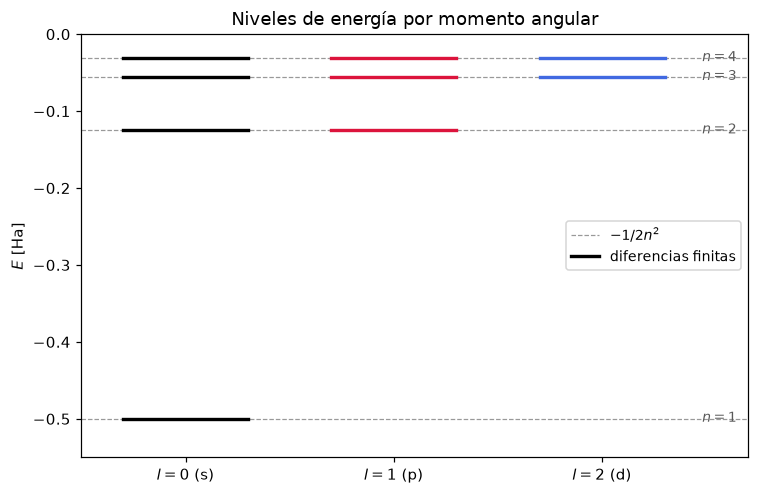

In [6]:
colores = ["black", "crimson", "royalblue"]

fig, ax = plt.subplots(figsize=(7.0, 4.6))
for n in range(1, n_max + 1):
    ax.axhline(-1.0/(2.0*n*n), color="0.6", ls="--", lw=0.8, zorder=0)
    ax.text(2.48, -1.0/(2.0*n*n), f"$n={n}$", va="center", fontsize=9, color="0.35")
for (n, l), energia in energias.items():
    ax.plot([l - 0.3, l + 0.3], [energia, energia], color=colores[l], lw=2.2)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["$l=0$ (s)", "$l=1$ (p)", "$l=2$ (d)"])
ax.set_xlim(-0.5, 2.7)
ax.set_ylim(-0.55, 0.0)
ax.set_ylabel("$E$ [Ha]")
ax.set_title("Niveles de energía por momento angular")
ax.plot([], [], color="0.6", ls="--", lw=0.8, label="$-1/2n^2$")
ax.plot([], [], color="black", lw=2.2, label="diferencias finitas")
ax.legend(loc="center right", fontsize=9)
fig.tight_layout()
plt.show()

Los estados con el mismo $n$ y distinto $l$ caen sobre la misma energía, la degeneración en $l$ del
potencial de Coulomb. El error relativo mayor es el del $1s$, $2.5\times10^{-5}$; en los estados $d$
queda por debajo de $3.1\times10^{-7}$.

---

# 5. Funciones radiales

**Polinomio.** Con $\lambda=n$, la ecuación para $v$ de la sección 4 es

$$\rho\,v''+(\alpha+1-\rho)\,v'+k\,v=0,\qquad\alpha=2l+1,\quad k=n-l-1,$$

la ecuación de Laguerre asociada, cuya solución polinómica de grado $k$ es $L^{\alpha}_k(\rho)$. Los
polinomios se calculan con la recurrencia

$$L^{\alpha}_0=1,\qquad L^{\alpha}_1=1+\alpha-\rho,\qquad
L^{\alpha}_{k+1}=\frac{(2k+1+\alpha-\rho)\,L^{\alpha}_k-(k+\alpha)\,L^{\alpha}_{k-1}}{k+1}.$$

**Función radial.** Con $\rho=2\kappa r=2r/n$, $r=n\rho/2$ y $R=u/r$:

$$R_{nl}(r)=\frac{\rho^{l+1}e^{-\rho/2}\,L^{2l+1}_{n-l-1}(\rho)}{n\rho/2}
\;\propto\;e^{-r/n}\,\rho^{\,l}\,L^{2l+1}_{n-l-1}(\rho),$$

y se escribe $R_{nl}=C\,e^{-r/n}\,\rho^{\,l}\,L^{2l+1}_{n-l-1}(\rho)$.

**Normalización.** $\int_0^\infty R^2\,r^2\,dr=1$. Con $r=n\rho/2$ y $dr=(n/2)\,d\rho$:

$$C^2\left(\frac{n}{2}\right)^3\int_0^\infty\rho^{2l+2}\,e^{-\rho}\left[L^{2l+1}_{n-l-1}(\rho)\right]^2d\rho=1.$$

La integral sale de dos propiedades de los polinomios. Despejando $\rho\,L^{\alpha}_k$ de la
recurrencia:

$$\rho\,L^{\alpha}_k=(2k+\alpha+1)\,L^{\alpha}_k-(k+1)\,L^{\alpha}_{k+1}-(k+\alpha)\,L^{\alpha}_{k-1},$$

y la ortogonalidad:

$$\int_0^\infty\rho^{\alpha}e^{-\rho}\,L^{\alpha}_j\,L^{\alpha}_k\,d\rho=\frac{(k+\alpha)!}{k!}\,\delta_{jk}.$$

Entonces, escribiendo $\rho^{\alpha+1}[L^{\alpha}_k]^2=\rho^{\alpha}L^{\alpha}_k\,(\rho\,L^{\alpha}_k)$,
los términos con $L^{\alpha}_{k+1}$ y $L^{\alpha}_{k-1}$ se anulan y queda

$$\int_0^\infty\rho^{\alpha+1}e^{-\rho}\left[L^{\alpha}_k\right]^2d\rho=(2k+\alpha+1)\,\frac{(k+\alpha)!}{k!}.$$

Con $\alpha=2l+1$ y $k=n-l-1$: $\alpha+1=2l+2$, $2k+\alpha+1=2n$ y $k+\alpha=n+l$, así que

$$\int_0^\infty\rho^{2l+2}e^{-\rho}\left[L^{2l+1}_{n-l-1}\right]^2d\rho=\frac{2n\,(n+l)!}{(n-l-1)!}.$$

Reemplazando en la normalización:

$$\boxed{R_{nl}(r)=\sqrt{\left(\frac{2}{n}\right)^3\frac{(n-l-1)!}{2n\,(n+l)!}}\;e^{-r/n}\,\rho^{\,l}\,
L^{2l+1}_{n-l-1}(\rho),\qquad\rho=\frac{2r}{n}}$$

que es la misma expresión de la [sesión 2.3](https://github.com/anferivera/Fisica_Computacional_1/blob/main/Sesiones/PDE/2.3_FDM_schrodinger.ipynb). La comparación se hace sobre $u_{nl}(r)=r\,R_{nl}(r)$, que
es la función que sale de la iteración inversa.

In [7]:
def factorial(m):
    """m! con un ciclo."""
    producto = 1.0
    for j in range(2, m + 1):
        producto *= j
    return producto


def laguerre(k, alfa, x):
    """Polinomio asociado de Laguerre por recurrencia."""
    if k == 0:
        return 1.0
    anterior = 1.0
    actual = 1.0 + alfa - x
    for m in range(1, k):
        siguiente = ((2*m + 1 + alfa - x)*actual - (m + alfa)*anterior)/(m + 1)
        anterior = actual
        actual = siguiente
    return actual


def radial_exacta(n, l, radio):
    """R_nl(r) analitica en unidades atomicas."""
    coeficiente = math.sqrt((2.0/n)**3*factorial(n - l - 1)/(2.0*n*factorial(n + l)))
    rho = 2.0*radio/n
    return coeficiente*math.exp(-radio/n)*rho**l*laguerre(n - l - 1, 2*l + 1, rho)


u_analitica = {}
for (n, l), u in funciones.items():
    u_analitica[(n, l)] = np.zeros(nodos)
    diferencia = 0.0
    for i in range(nodos):
        u_analitica[(n, l)][i] = r[i]*radial_exacta(n, l, r[i])
        if abs(u[i] - u_analitica[(n, l)][i]) > diferencia:
            diferencia = abs(u[i] - u_analitica[(n, l)][i])
    print(f"{n}{letras[l]}  max |u_num - u_exacta| = {diferencia:.1e}")

1s  max |u_num - u_exacta| = 1.0e-05
2s  max |u_num - u_exacta| = 6.6e-06
3s  max |u_num - u_exacta| = 3.1e-06
4s  max |u_num - u_exacta| = 7.9e-05
2p  max |u_num - u_exacta| = 2.1e-06
3p  max |u_num - u_exacta| = 2.2e-06
4p  max |u_num - u_exacta| = 6.5e-05
3d  max |u_num - u_exacta| = 1.8e-07
4d  max |u_num - u_exacta| = 4.2e-05


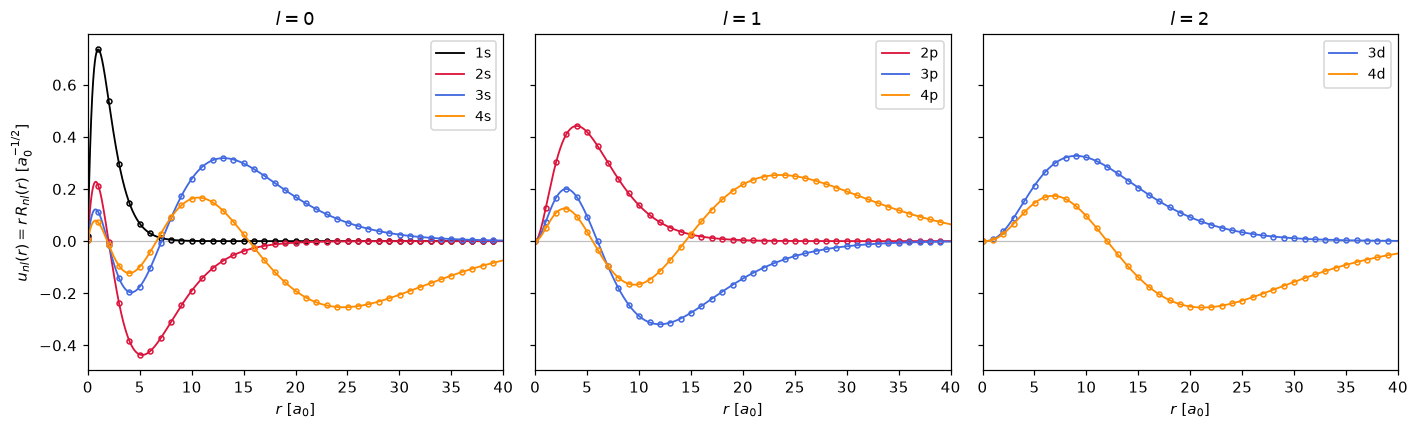

In [8]:
tonos = {1: "black", 2: "crimson", 3: "royalblue", 4: "darkorange"}
salto = 100
r_grafica = 40.0

fig, ejes = plt.subplots(1, 3, figsize=(13.0, 4.0), sharey=True)
for l in range(3):
    ax = ejes[l]
    for n in range(l + 1, n_max + 1):
        muestra_r = []
        muestra_u = []
        for i in range(0, nodos, salto):
            if r[i] <= r_grafica:
                muestra_r.append(r[i])
                muestra_u.append(funciones[(n, l)][i])
        ax.plot(r, u_analitica[(n, l)], color=tonos[n], lw=1.2, label=f"{n}{letras[l]}")
        ax.plot(muestra_r, muestra_u, "o", ms=3.2, color=tonos[n], mfc="none")
    ax.axhline(0.0, color="0.75", lw=0.8, zorder=0)
    ax.set_xlim(0.0, r_grafica)
    ax.set_xlabel("$r$ [$a_0$]")
    ax.set_title(f"$l={l}$")
    ax.legend(fontsize=9)
ejes[0].set_ylabel(r"$u_{nl}(r)=r\,R_{nl}(r)$ [$a_0^{-1/2}$]")
fig.tight_layout()
plt.show()

Línea: $u_{nl}$ analítica. Círculos: $u_i$ de la iteración inversa, uno cada $100$ nodos.

**Función de onda en un plano.** Para $l=0$, una $Y$ constante cumple la ecuación angular del paso 2:
sus dos derivadas son cero y el lado derecho es $-l(l+1)\,Y=0$. Con la normalización del paso 6:

$$\int|Y|^2\,d\Omega=4\pi\,Y^2=1\quad\Rightarrow\quad Y_{00}=\frac{1}{\sqrt{4\pi}},\qquad
\psi_{n00}(\vec{r})=\frac{u_{n0}(r)}{r\sqrt{4\pi}}.$$

En el plano $xz$, $r=\sqrt{x^2+z^2}$, y entre dos nodos de la malla $u$ se interpola en línea recta:

$$u(r)\approx(1-t)\,u_i+t\,u_{i+1},\qquad i=\lfloor r/h\rfloor,\qquad t=\frac{r}{h}-i.$$

Entre $r=0$ y $r=h$, con $u_0=0$, queda $u/r=u_1/h$.

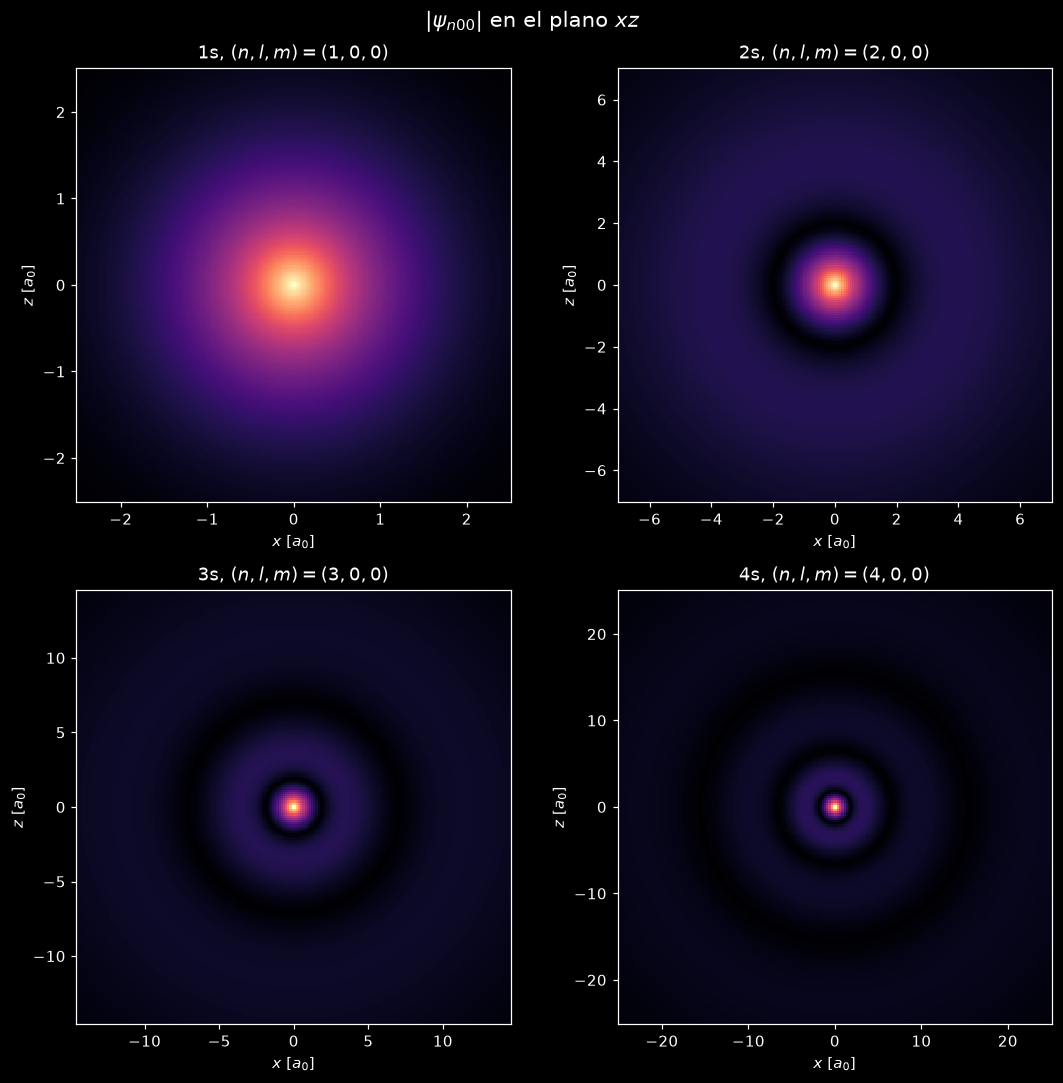

In [9]:
def psi_s(u, radio):
    """|psi_n00| en un radio, con u interpolada entre los dos nodos vecinos."""
    i = int(radio/paso)
    if i == 0:
        return abs(u[0]/paso)/math.sqrt(4.0*math.pi)
    t = radio/paso - i
    u_radio = (1.0 - t)*u[i-1] + t*u[i]
    return abs(u_radio/radio)/math.sqrt(4.0*math.pi)


puntos = 200

with plt.style.context("dark_background"):
    fig, ejes = plt.subplots(2, 2, figsize=(10.0, 10.0))
    for n in range(1, n_max + 1):
        ax = ejes[(n - 1)//2][(n - 1) % 2]
        lado = 1.5*n*n + 1.0
        eje = np.zeros(puntos)
        for k in range(puntos):
            eje[k] = -lado + 2.0*lado*k/(puntos - 1)
        mapa = np.zeros((puntos, puntos))
        for fila in range(puntos):
            for columna in range(puntos):
                radio = math.sqrt(eje[columna]**2 + eje[fila]**2)
                mapa[fila, columna] = psi_s(funciones[(n, 0)], radio)
        ax.pcolormesh(eje, eje, mapa, cmap="magma", shading="nearest")
        ax.set_aspect("equal")
        ax.set_xlabel("$x$ [$a_0$]")
        ax.set_ylabel("$z$ [$a_0$]")
        ax.set_title(f"{n}s, $(n,l,m)=({n},0,0)$")
    fig.suptitle(r"$|\psi_{n00}|$ en el plano $xz$", fontsize=14)
    fig.tight_layout()
    plt.show()

El plano va de $-L$ a $L$ con $L=1.5\,n^2+1$ $a_0$ y los colores son los de `Hydrogen_WaveFunction`, como en la
[sesión 2.3](https://github.com/anferivera/Fisica_Computacional_1/blob/main/Sesiones/PDE/2.3_FDM_schrodinger.ipynb).
Los anillos oscuros son los ceros de $u_{n0}$.

---

## Referencias

- Material del curso:
  [`Sesiones/PDE/2.1_Finite_Differece_Method_FDM.ipynb`](https://github.com/anferivera/Fisica_Computacional_1/blob/main/Sesiones/PDE/2.1_Finite_Differece_Method_FDM.ipynb),
  para la segunda derivada centrada por series de Taylor, y
  [`Sesiones/PDE/2.3_FDM_schrodinger.ipynb`](https://github.com/anferivera/Fisica_Computacional_1/blob/main/Sesiones/PDE/2.3_FDM_schrodinger.ipynb),
  para la ecuación del átomo de hidrógeno, la solución analítica y la función de onda en un plano
  (`Hydrogen_WaveFunction`).
- G. H. Golub y C. F. Van Loan, *Matrix Computations*, 4.ª ed., Johns Hopkins University Press
  (2013), capítulo 8, para la ley de inercia de Sylvester, la bisección con conteo de Sturm y la
  iteración inversa sobre matrices tridiagonales simétricas.
- NIST Digital Library of Mathematical Functions, tablas 18.3.1, 18.8.1 y 18.9.1, para la
  ortogonalidad, la ecuación diferencial y la recurrencia de los polinomios de Laguerre.